# Analisis de mercado de Criptomonedas



1. Resumen Ejecutivo
El presente proyecto consiste en el desarrollo de un Pipeline de Minería de Datos enfocado en el mercado financiero de criptomonedas. El objetivo principal es extraer, procesar y analizar el comportamiento histórico de los 10 activos con mayor capitalización de mercado. A diferencia de los análisis de corto plazo, este estudio utiliza datos de frecuencia diaria (1d), lo que permite capturar ciclos de mercado completos y tendencias estructurales desde el año 2015 hasta la actualidad.



2. Contexto y Problemática
En el ámbito del trading y la gestión de activos digitales, la alta volatilidad diaria representa el mayor desafío. Este proyecto busca mitigar la incertidumbre mediante el Análisis Exploratorio de Datos (EDA), permitiendo identificar patrones de correlación de largo plazo entre activos líderes (como Bitcoin y Ethereum) y el resto del mercado. El uso de datos diarios proporciona una base sólida para la toma de decisiones estratégicas y la gestión de riesgos en portafolios de inversión.



# 3. Objetivos Técnicos


## Extracción Automatizada: Implementar un motor de captura de datos históricos diarios utilizando la API de Yahoo Finance.

1. Instalar yfinance si no está en el entorno.
2. Configuración de fechas: Historial largo desde 2015.
3. CAMBIO: interval='1d' para datos diarios.
4. Aplanamos las columnas si vienen con MultiIndex.
5. Guardamos el DataFrame en el diccionario.
6. Recorremos cada moneda guardada en nuestra base de datos.
7. Usamos display para que Colab muestre la tabla con formato profesional.
8. Imprimimos un resumen rápido debajo de cada tabla.


In [20]:
!pip install yfinance

import yfinance as yf
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [21]:
top_10_cryptos = {
    "Bitcoin": "BTC-USD",
    "Ethereum": "ETH-USD",
    "XRP": "XRP-USD",
    "Solana": "SOL-USD",
    "BNB": "BNB-USD",
    "Dogecoin": "DOGE-USD",
    "Cardano": "ADA-USD",
    "TRON": "TRX-USD",
    "Chainlink": "LINK-USD",
    "Polkadot": "DOT-USD"
}


fecha_inicio = '2015-01-01'
fecha_fin = datetime.now().strftime('%Y-%m-%d')

crypto_database = {}

In [22]:
print(f"Descargando datos DIARIOS desde {fecha_inicio} hasta hoy...\n")

for nombre, ticker in top_10_cryptos.items():
    try:

        df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)

        if not df.empty:

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)


            crypto_database[nombre] = df
            print(f" {nombre} cargado: {len(df)} días registrados.")
        else:
            print(f" No hay datos para {nombre}")

    except Exception as e:
        print(f" Error en {nombre}: {e}")

print("\n--- Descarga completada ---")

Descargando datos DIARIOS desde 2015-01-01 hasta hoy...

 Bitcoin cargado: 4135 días registrados.
 Ethereum cargado: 3092 días registrados.
 XRP cargado: 3092 días registrados.


/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_f

 Solana cargado: 2209 días registrados.
 BNB cargado: 3092 días registrados.


/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)
/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)


 Dogecoin cargado: 3092 días registrados.
 Cardano cargado: 3092 días registrados.
 TRON cargado: 3092 días registrados.
 Chainlink cargado: 3092 días registrados.
 Polkadot cargado: 2077 días registrados.

--- Descarga completada ---


/tmp/ipykernel_4627/153219632.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, interval='1d', progress=False)


In [23]:
for nombre, df in crypto_database.items():
    print("\n" + "="*70)
    print(f" DATASET: {nombre.upper()} ({top_10_cryptos[nombre]})")
    print(f"Muestra: Primeros 100 registros | Intervalo: 1 Día")
    print("="*70)


    display(df.head(100))


    print(f" Total de días procesados para {nombre}: {len(df)}")
    print("-" * 70 + "\n")


 DATASET: BITCOIN (BTC-USD)
Muestra: Primeros 100 registros | Intervalo: 1 Día


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800
...,...,...,...,...,...
2015-04-06,255.492004,261.798004,254.574997,260.721008,20034200
2015-04-07,253.179993,255.804993,252.205002,255.274002,18467400
2015-04-08,245.022003,253.847000,244.214996,253.063995,30086400


 Total de días procesados para Bitcoin: 4135
----------------------------------------------------------------------


 DATASET: ETHEREUM (ETH-USD)
Muestra: Primeros 100 registros | Intervalo: 1 Día


Price,Close,High,Low,Open,Volume
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984
...,...,...,...,...,...
2018-02-12,868.706970,875.937012,817.507996,817.507996,2243450112
2018-02-13,845.257996,870.708984,828.836975,869.293030,2081170048
2018-02-14,923.560974,926.429016,844.278992,844.278992,2818370048


 Total de días procesados para Ethereum: 3092
----------------------------------------------------------------------


 DATASET: XRP (XRP-USD)
Muestra: Primeros 100 registros | Intervalo: 1 Día


...

 Total de días procesados para TRON: 3092
----------------------------------------------------------------------


 DATASET: CHAINLINK (LINK-USD)
Muestra: Primeros 100 registros | Intervalo: 1 Día


Price,Close,High,Low,Open,Volume
Date,,,,,
2017-11-09,0.223969,0.248233,0.195411,0.216713,3347920
2017-11-10,0.187602,0.231280,0.180161,0.224700,2125460
2017-11-11,0.179770,0.197687,0.166026,0.186398,2238980
2017-11-12,0.170898,0.198376,0.145948,0.179667,5455200
2017-11-13,0.183071,0.205014,0.168743,0.169117,2992650
...,...,...,...,...,...
2018-02-12,0.490282,0.519708,0.414619,0.417541,7646360
2018-02-13,0.570759,0.624750,0.482524,0.488930,30283200
2018-02-14,0.568253,0.587916,0.532434,0.564205,11953100


 Total de días procesados para Chainlink: 3092
----------------------------------------------------------------------


 DATASET: POLKADOT (DOT-USD)
Muestra: Primeros 100 registros | Intervalo: 1 Día


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-08-20,2.900080,3.077784,2.692896,2.787857,48819867
2020-08-21,2.875028,3.090093,2.730919,2.896923,49313137
2020-08-22,4.484690,4.510613,2.816762,2.878570,485801096
2020-08-23,3.967066,4.487058,3.716271,4.487058,320749483
2020-08-24,4.602614,4.783158,3.812670,3.987413,407690171
...,...,...,...,...,...
2020-11-23,5.906932,5.939078,5.422479,5.481854,997956277
2020-11-24,5.729446,6.075694,5.624484,5.907906,1113438978
2020-11-25,5.309860,5.816350,5.183073,5.729335,1011116414


 Total de días procesados para Polkadot: 2077
----------------------------------------------------------------------




# Estandarización y Limpieza: Realizar un mapeo de datos y una revisión exhaustiva de los tipos informáticos (numéricos continuos vs. categóricos) para asegurar la integridad del dataset.

1. Mapeo de nombres de columnas (Estandarización al español).

2. INTEGRIDAD(1): Eliminación de registros duplicados.

3. INTEGRIDAD(2): Manejo de Valores Nulos (Missing Values)

    Usamos ffill() para rellenar nulos con el precio del día anterior (práctica estándar en finanzas).

4. Los df.ffill(inplace=True) Rellena hacia adelante y df.bfill(inplace=True) Rellena hacia atrás por si el primer día es nulo

5. MAPEO DE DATOS: Renombrar las columnas.

6. REVISIÓN Y CASTING DE TIPOS INFORMÁTICOS

    Aseguramos que todas las variables (precio y volumen) sean tratadas como float64 (Numérico)
7. REVISIÓN Y CASTING DE TIPOS INFORMÁTICOS
    Aseguramos que todas las variables (precio y volumen) sean tratadas como float64 (Numérico)
8. Actualizamos el diccionario con el DataFrame limpio
9. Usamos Bitcoin como muestra para el reporte de metadatos de la entrega
10. Todas las variables de mercado financiero son Numéricas Continuas
11. Mostramos la tabla final de tipos para el profesor

In [24]:
print("=== INICIANDO PROCESO DE ESTANDARIZACIÓN Y LIMPIEZA ===\n")


mapeo_columnas = {
    'Open': 'apertura',
    'High': 'maximo',
    'Low': 'minimo',
    'Close': 'cierre',
    'Adj Close': 'cierre_ajustado',
    'Volume': 'volumen'
}

for nombre, df in crypto_database.items():
    filas_iniciales = len(df)


    df.drop_duplicates(inplace=True)



    nulos_previos = df.isnull().sum().sum()
    if nulos_previos > 0:
        df.ffill(inplace=True)
        df.bfill(inplace=True)


    df.rename(columns=lambda x: mapeo_columnas.get(x, x), inplace=True)



    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')


    crypto_database[nombre] = df

    print(f" {nombre}: {filas_iniciales} días revisados | {nulos_previos} valores nulos corregidos.")

print("\n=== REVISIÓN EXHAUSTIVA DE TIPOS DE DATOS (MAPEO FINAL) ===\n")


df_muestra = crypto_database["Bitcoin"]


reporte_tipos = pd.DataFrame({
    'Columna Mapeada': df_muestra.columns,
    'Tipo Informático (Pandas)': df_muestra.dtypes.values,
    'Clasificación (Minería de Datos)': 'Numérica Continua',
    'Descripción del Dato': [
        'Precio de apertura del día',
        'Precio máximo del día',
        'Precio mínimo del día',
        'Precio de cierre del día',
        'Precio de cierre ajustado',
        'Volumen transado en el día'
    ][:len(df_muestra.columns)]
})


display(reporte_tipos)

=== INICIANDO PROCESO DE ESTANDARIZACIÓN Y LIMPIEZA ===

 Bitcoin: 4135 días revisados | 0 valores nulos corregidos.
 Ethereum: 3092 días revisados | 0 valores nulos corregidos.
 XRP: 3092 días revisados | 0 valores nulos corregidos.
 Solana: 2209 días revisados | 0 valores nulos corregidos.
 BNB: 3092 días revisados | 0 valores nulos corregidos.
 Dogecoin: 3092 días revisados | 0 valores nulos corregidos.
 Cardano: 3092 días revisados | 0 valores nulos corregidos.
 TRON: 3092 días revisados | 0 valores nulos corregidos.
 Chainlink: 3092 días revisados | 0 valores nulos corregidos.
 Polkadot: 2077 días revisados | 0 valores nulos corregidos.

=== REVISIÓN EXHAUSTIVA DE TIPOS DE DATOS (MAPEO FINAL) ===



,Columna Mapeada,Tipo Informático (Pandas),Clasificación (Minería de Datos),Descripción del Dato
0,cierre,float64,Numérica Continua,Precio de apertura del día
1,maximo,float64,Numérica Continua,Precio máximo del día
2,minimo,float64,Numérica Continua,Precio mínimo del día
3,apertura,float64,Numérica Continua,Precio de cierre del día
4,volumen,int64,Numérica Continua,Precio de cierre ajustado


# Análisis Estadístico: Evaluar la salud de los datos mediante medidas de tendencia central y dispersión, facilitando la comprensión del comportamiento histórico de cada activo.

1. Contar cuántos DataFrames hay en nuestro diccionario.

2. Si también quieres ver los nombres de esos DataFrames.


In [25]:
cantidad_dfs = len(crypto_database)

print(f"Actualmente tienes {cantidad_dfs} DataFrames (monedas) cargados en memoria.")

print("Monedas disponibles:", list(crypto_database.keys()))

Actualmente tienes 10 DataFrames (monedas) cargados en memoria.
Monedas disponibles: ['Bitcoin', 'Ethereum', 'XRP', 'Solana', 'BNB', 'Dogecoin', 'Cardano', 'TRON', 'Chainlink', 'Polkadot']


Generamos un grafico de tendencia de cada una de las monedas.

# Bitcoin


1. Seleccionamos la moneda a analizar.
2. GRÁFICO DE TENDENCIA HISTÓRICA.
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos).
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN.
5. Creamos una figura con dos subgráficos lado a lado.
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana

8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: BITCOIN ===



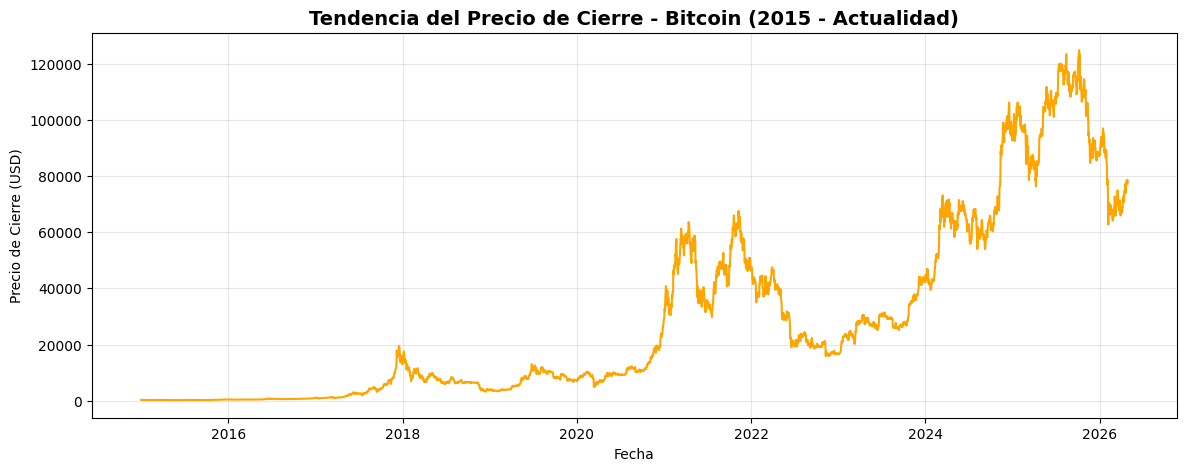


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 4135
Media (Promedio):        $28,912.46 USD
Mediana (Valor central): $11,959.37 USD
Desviación Estándar:     $32,361.57 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $178.10 a $124,752.53 USD



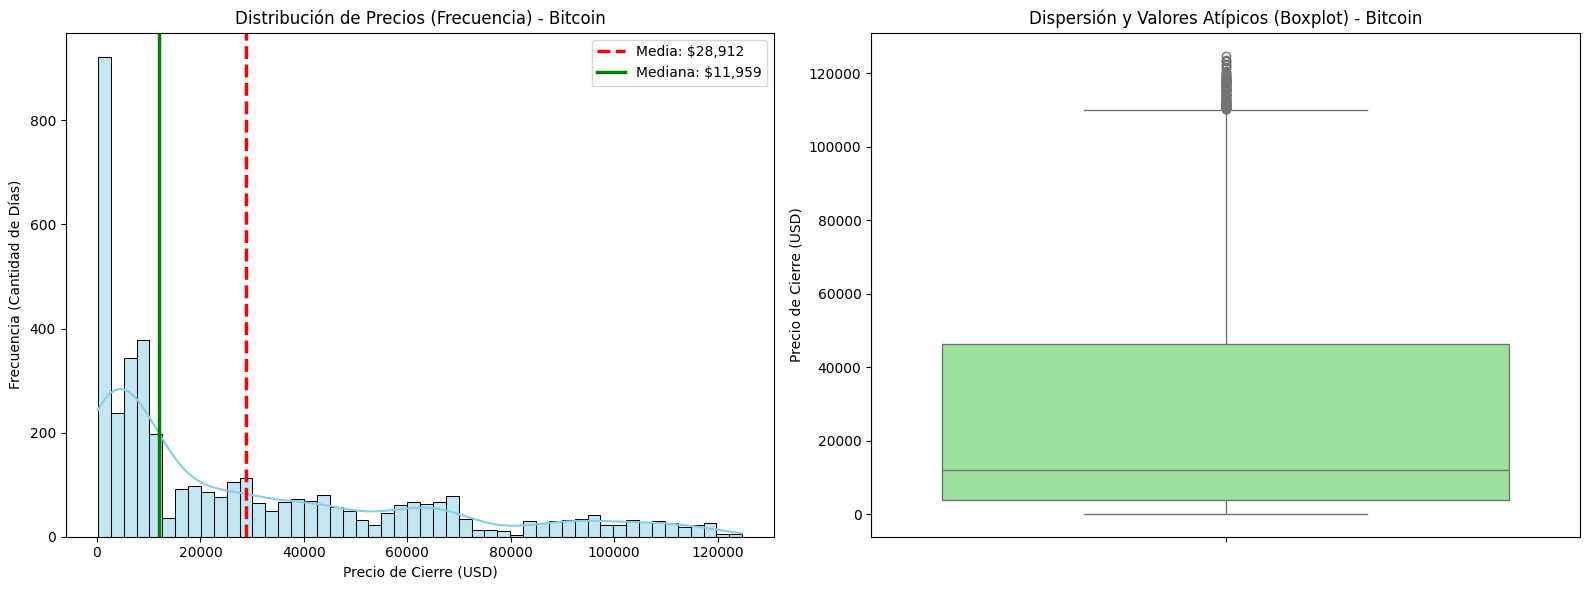

In [26]:
moneda = "Bitcoin"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")


plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()


media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()


sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# Ethereum


1. Seleccionamos la moneda a analizar

2. GRÁFICO DE TENDENCIA HISTÓRICA

3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)

4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN

5. Creamos una figura con dos subgráficos lado a lado

6. Gráfico A: Histograma (Distribución y Tendencia Central)

7. Dibujamos líneas para la Media y la Mediana

8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: ETHEREUM ===



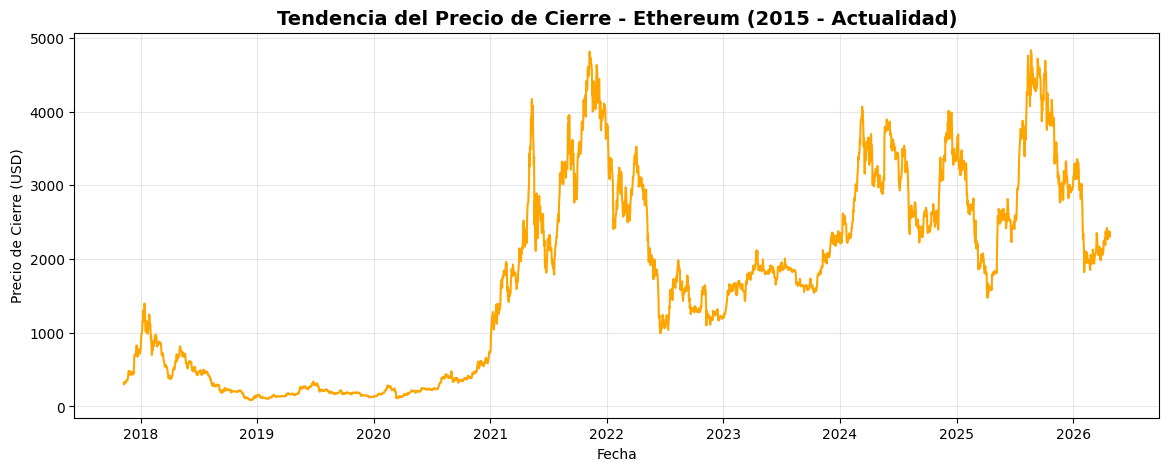


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $1,710.65 USD
Mediana (Valor central): $1,702.76 USD
Desviación Estándar:     $1,280.84 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $84.31 a $4,831.35 USD



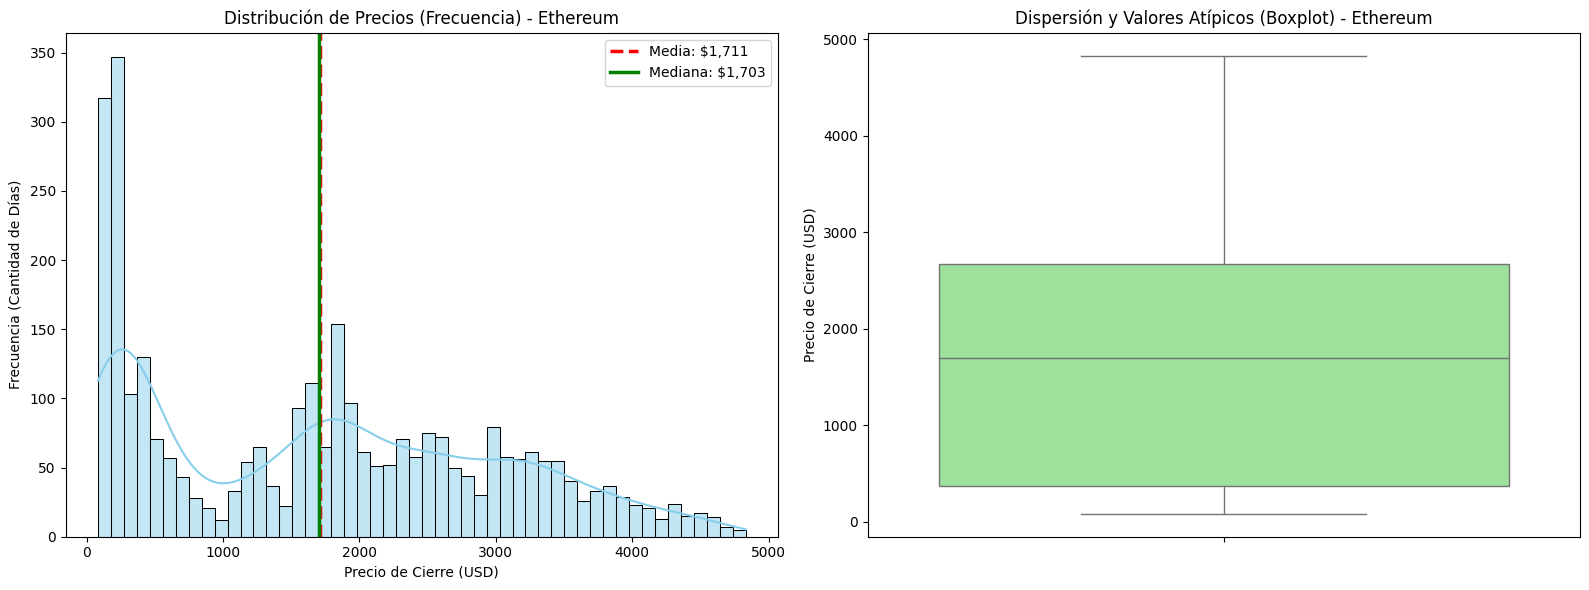

In [27]:
moneda = "Ethereum"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")


plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()


media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()


sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# XRP


1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: XRP ===



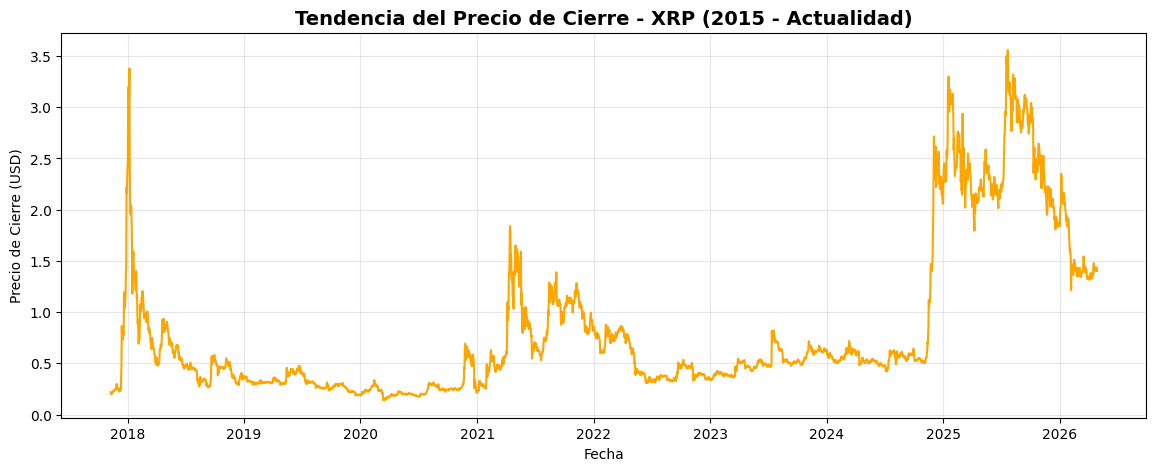


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $0.82 USD
Mediana (Valor central): $0.52 USD
Desviación Estándar:     $0.74 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $0.14 a $3.56 USD



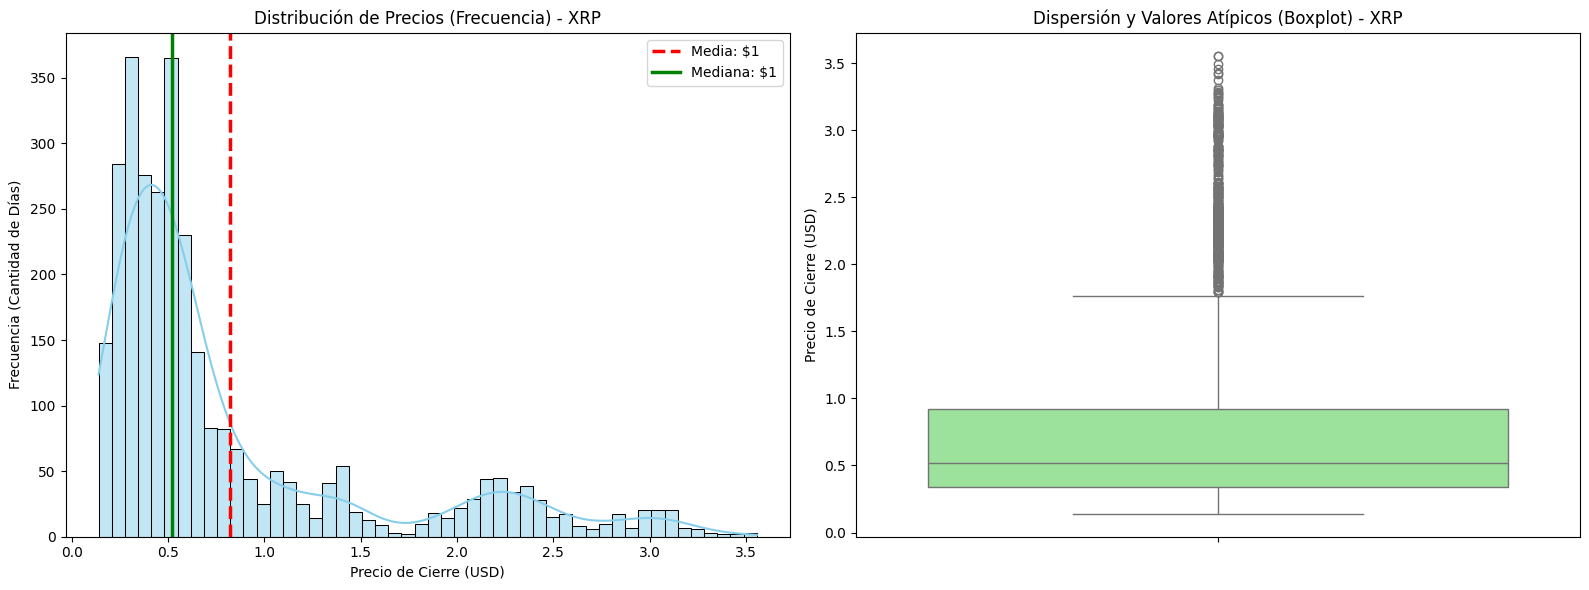

In [28]:
moneda = "XRP"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")


plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()


media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()


sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# Solana


1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: SOLANA ===



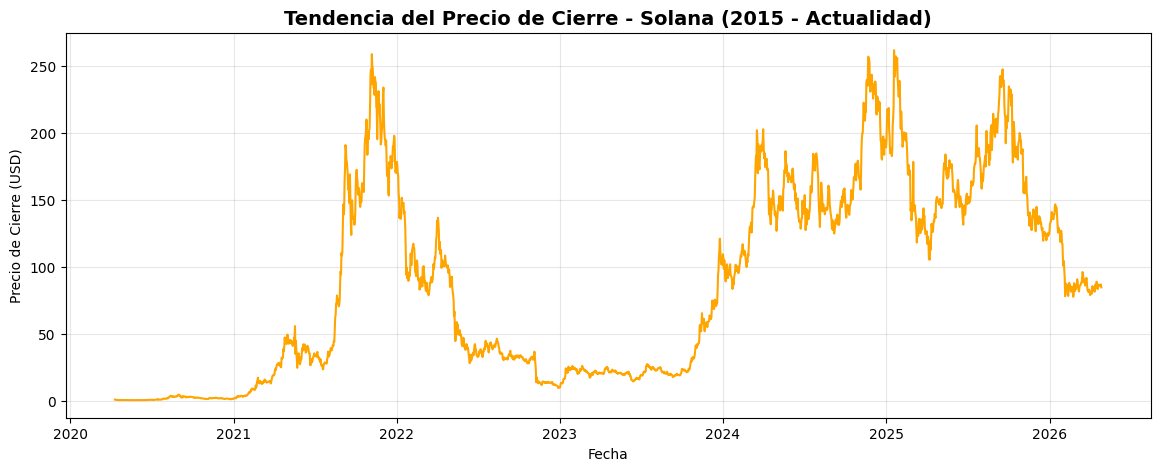


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 2209
Media (Promedio):        $86.88 USD
Mediana (Valor central): $80.37 USD
Desviación Estándar:     $72.45 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $0.52 a $261.87 USD



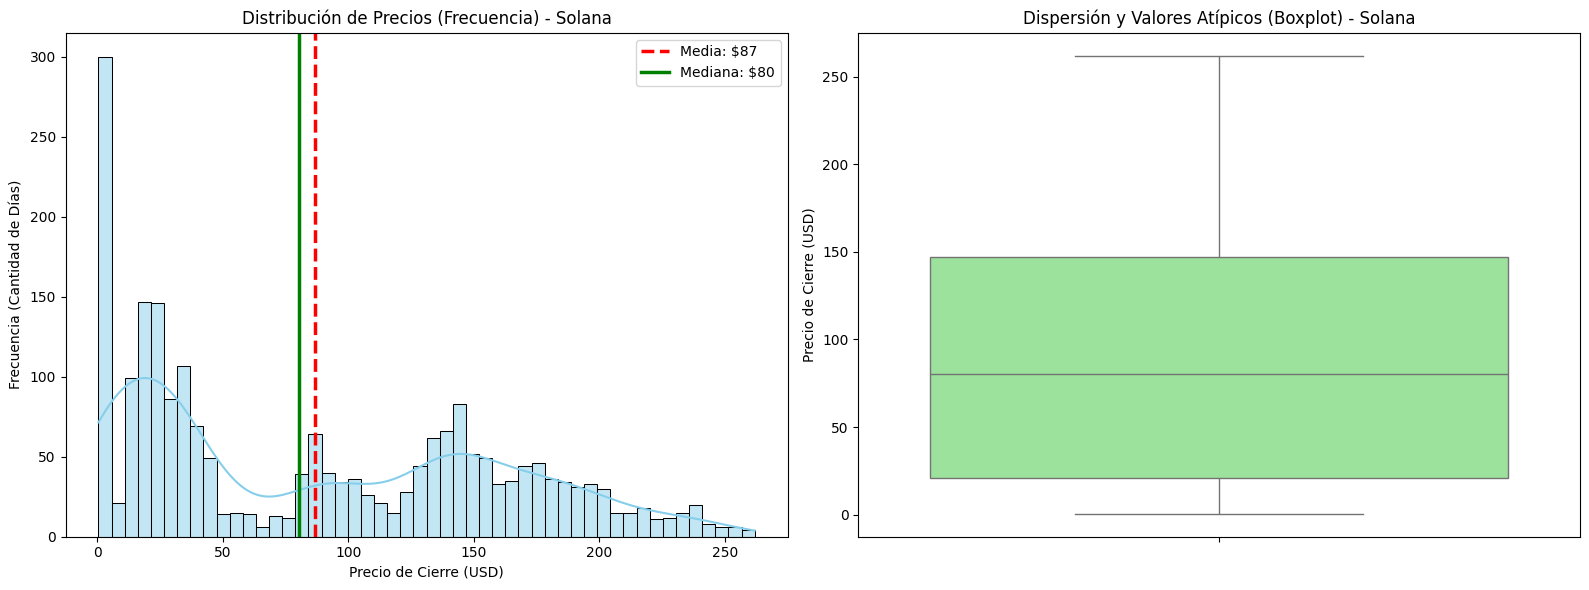

In [29]:
moneda = "Solana"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")

plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()

sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# BNB

1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: BNB ===



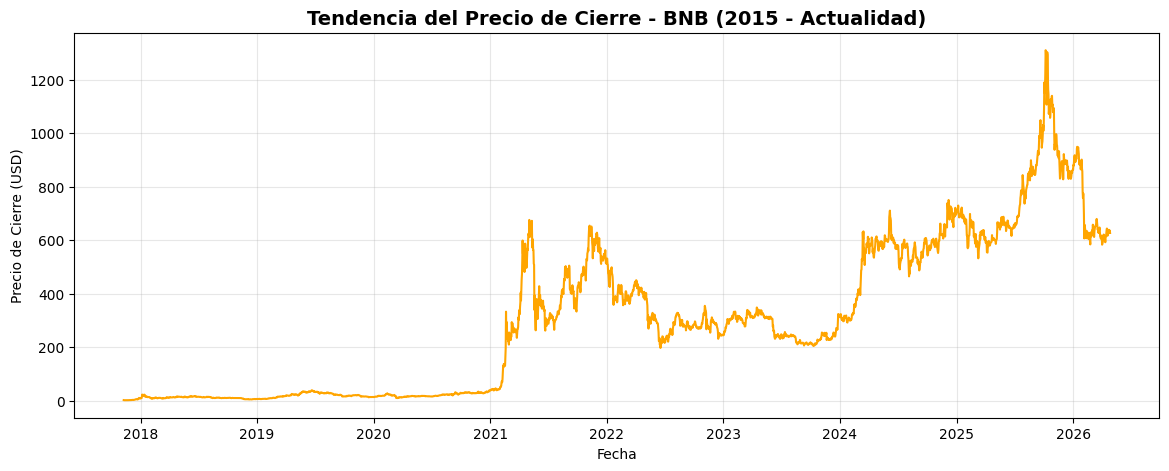


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $302.69 USD
Mediana (Valor central): $275.51 USD
Desviación Estándar:     $282.50 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $1.51 a $1,310.21 USD



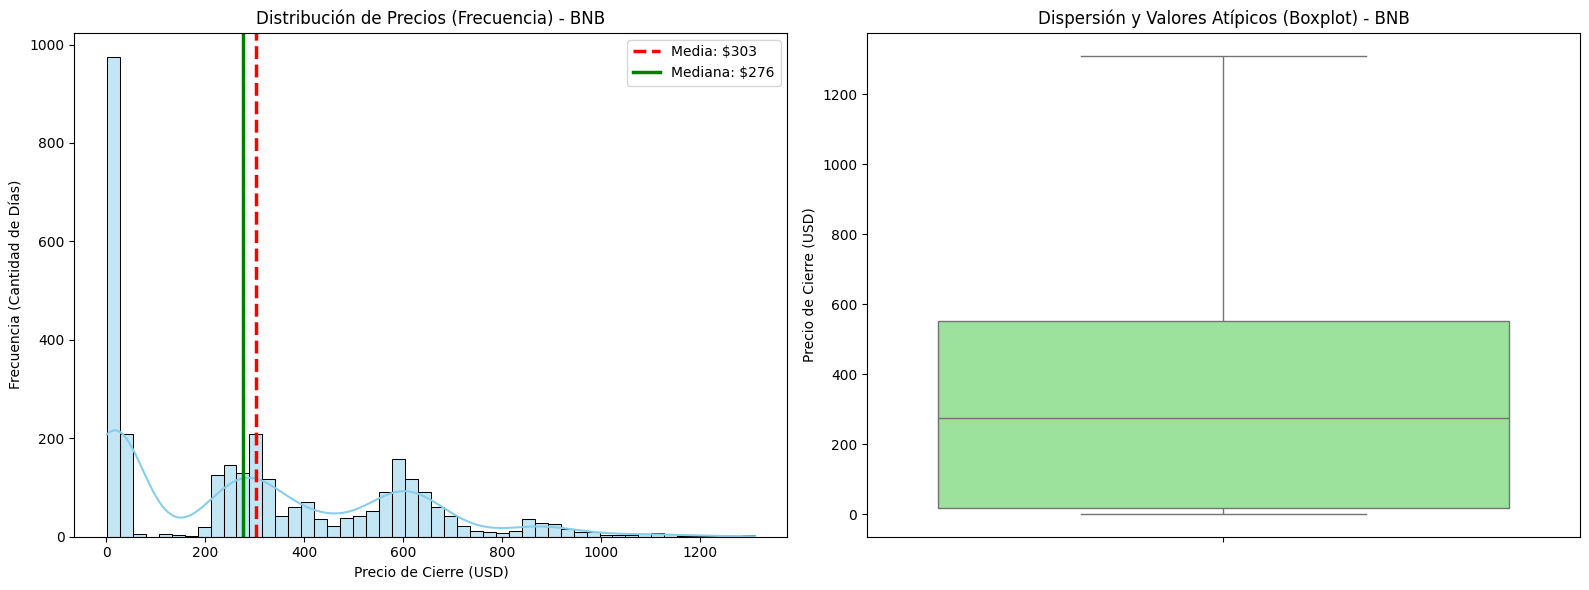

In [30]:
moneda = "BNB"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")

plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()


sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# Dogecoin

1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: DOGECOIN ===



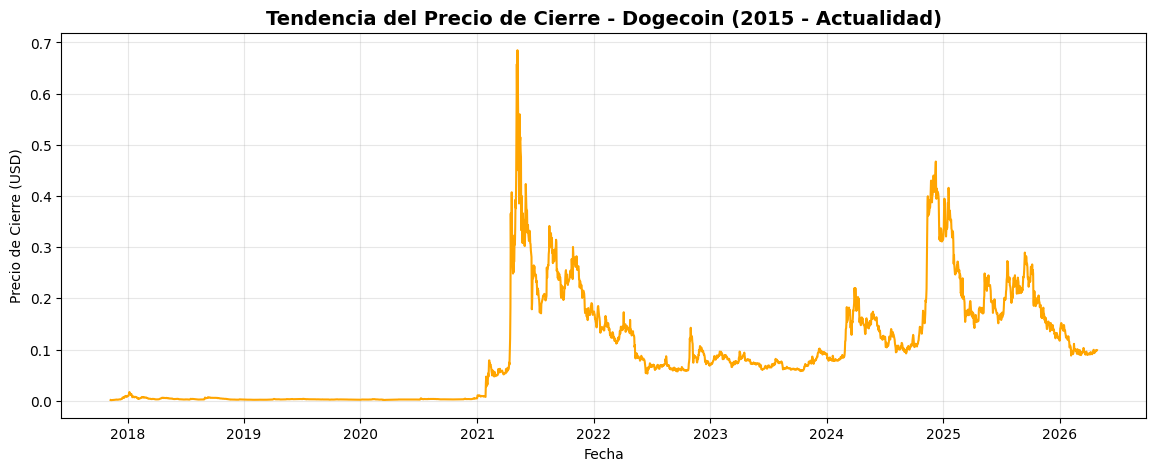


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $0.09 USD
Mediana (Valor central): $0.07 USD
Desviación Estándar:     $0.10 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $0.00 a $0.68 USD



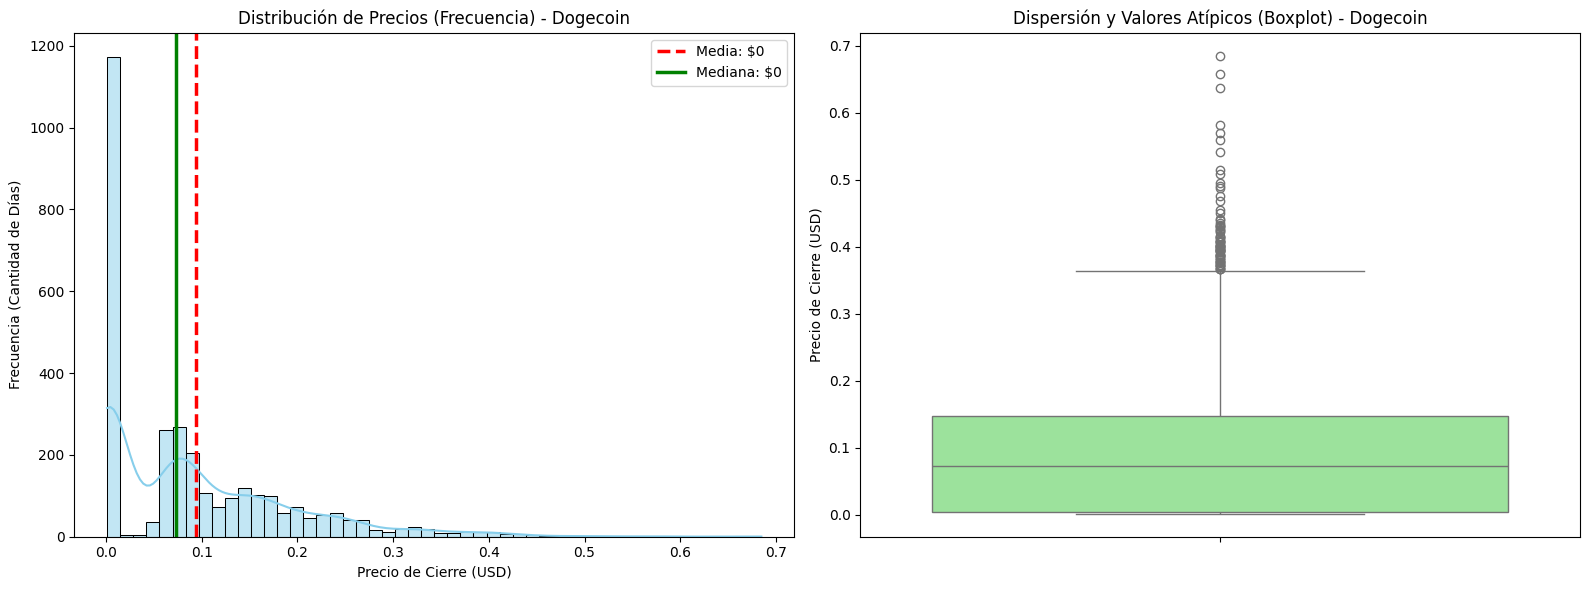

In [31]:
moneda = "Dogecoin"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")


plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()

sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# Cardano

1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: CARDANO ===



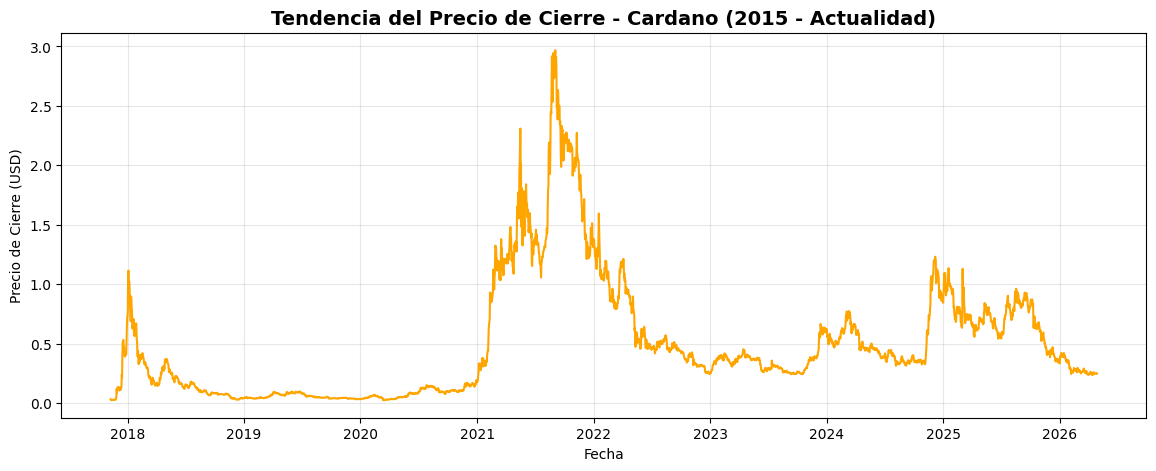


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $0.50 USD
Mediana (Valor central): $0.36 USD
Desviación Estándar:     $0.51 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $0.02 a $2.97 USD



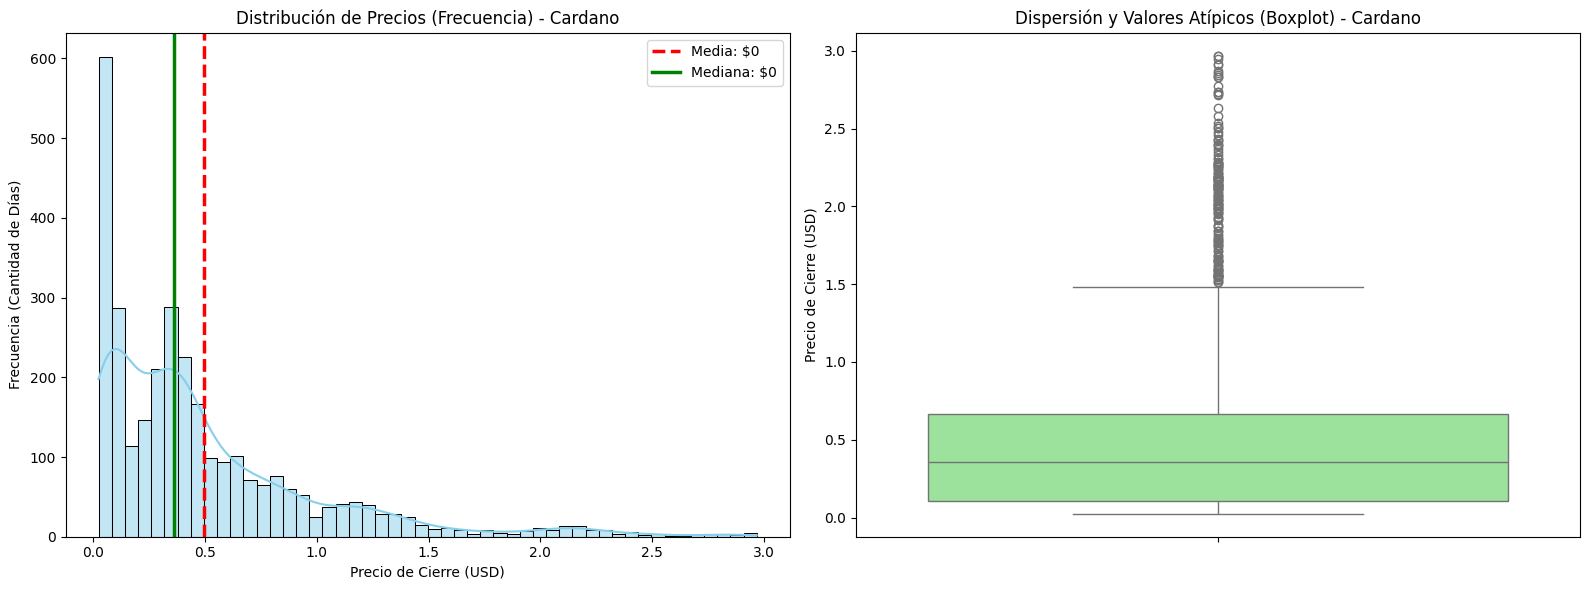

In [32]:
moneda = "Cardano"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")

plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()

sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# TRON

1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: TRON ===



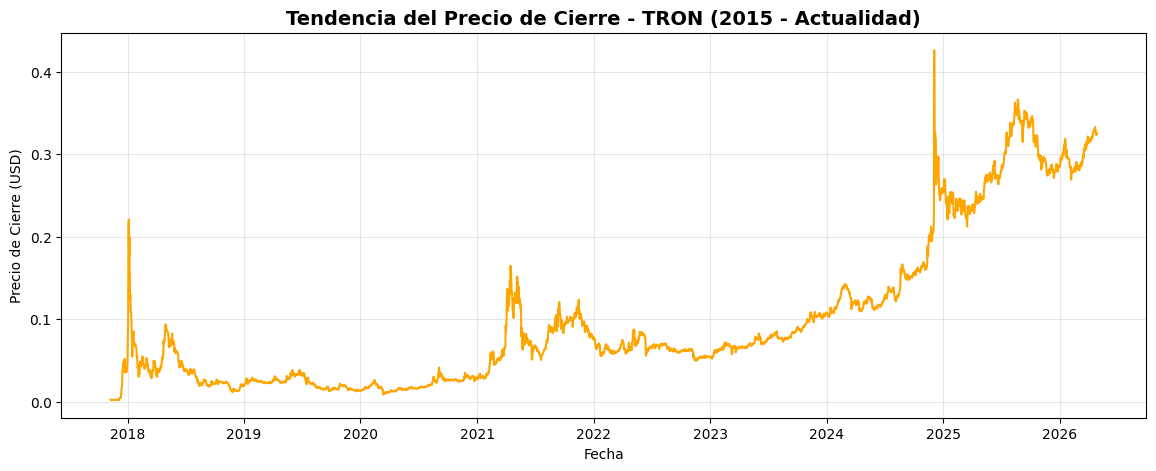


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $0.10 USD
Mediana (Valor central): $0.07 USD
Desviación Estándar:     $0.09 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $0.00 a $0.43 USD



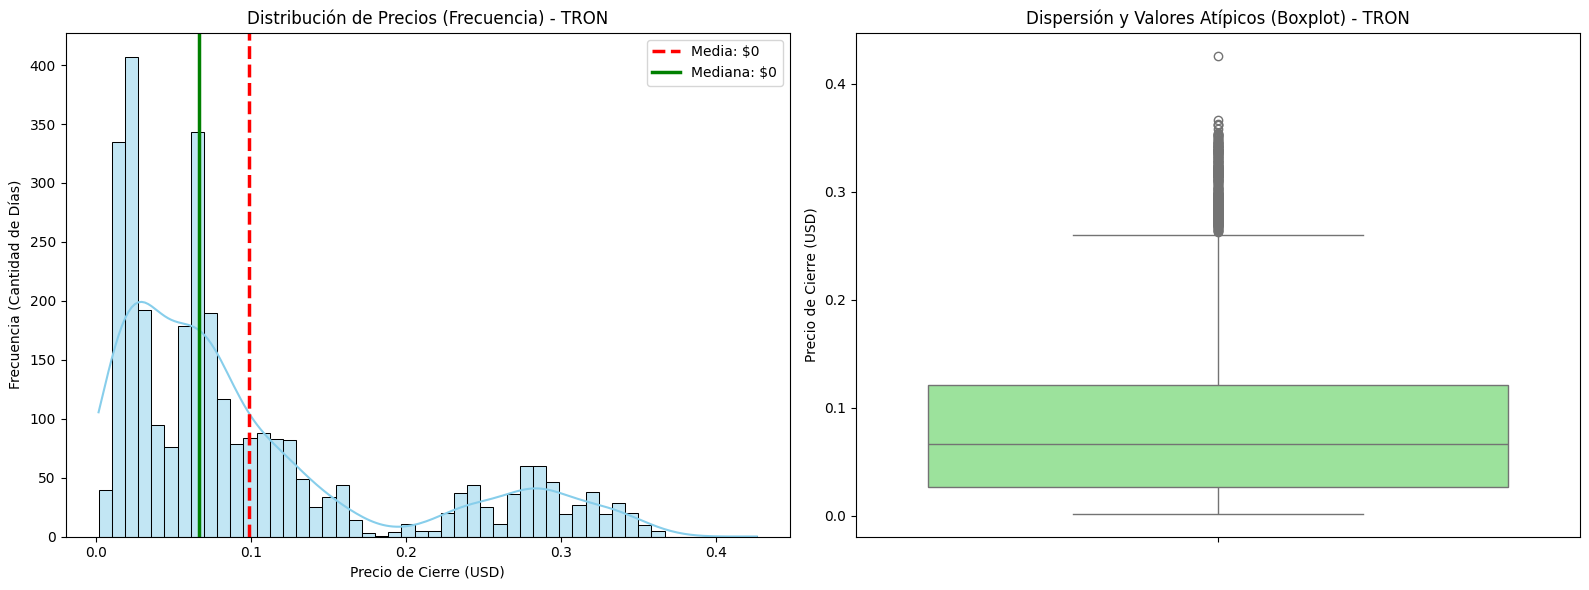

In [33]:
moneda = "TRON"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")

plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()

sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# Chainlink

1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: CHAINLINK ===



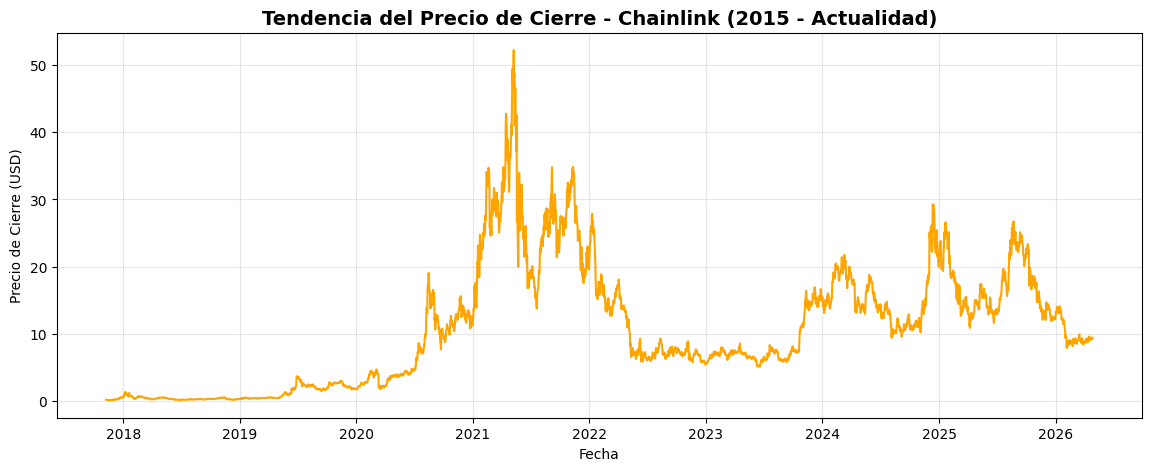


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 3092
Media (Promedio):        $10.68 USD
Mediana (Valor central): $8.77 USD
Desviación Estándar:     $8.97 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $0.15 a $52.20 USD



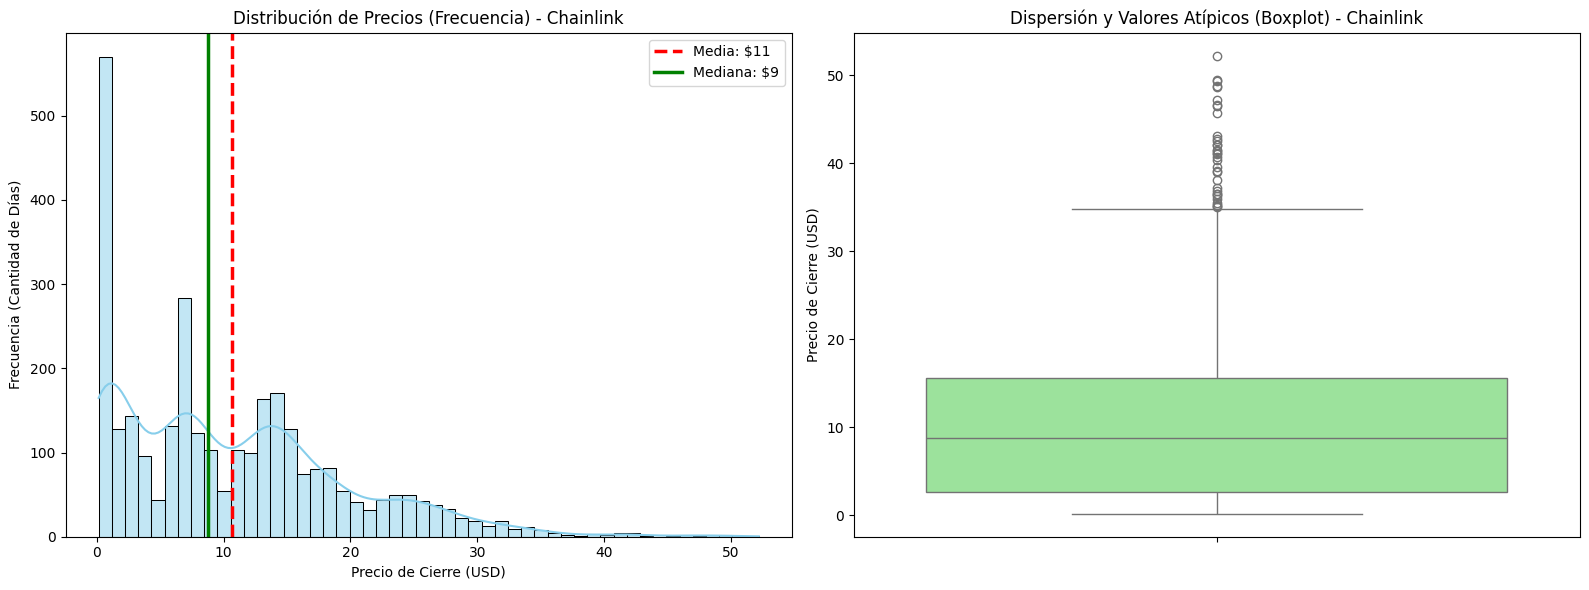

In [34]:
moneda = "Chainlink"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")

plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()

sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

# Polkadot

1. Seleccionamos la moneda a analizar
2. GRÁFICO DE TENDENCIA HISTÓRICA
3. CÁLCULO DE MEDIDAS ESTADÍSTICAS (Salud de los Datos)
4. VISUALIZACIÓN DE TENDENCIA CENTRAL Y DISPERSIÓN
5. Creamos una figura con dos subgráficos lado a lado
6. Gráfico A: Histograma (Distribución y Tendencia Central)
7. Dibujamos líneas para la Media y la Mediana
8. Gráfico B: Boxplot (Dispersión y Detección de Outliers)

=== INICIANDO ANÁLISIS PARA: POLKADOT ===



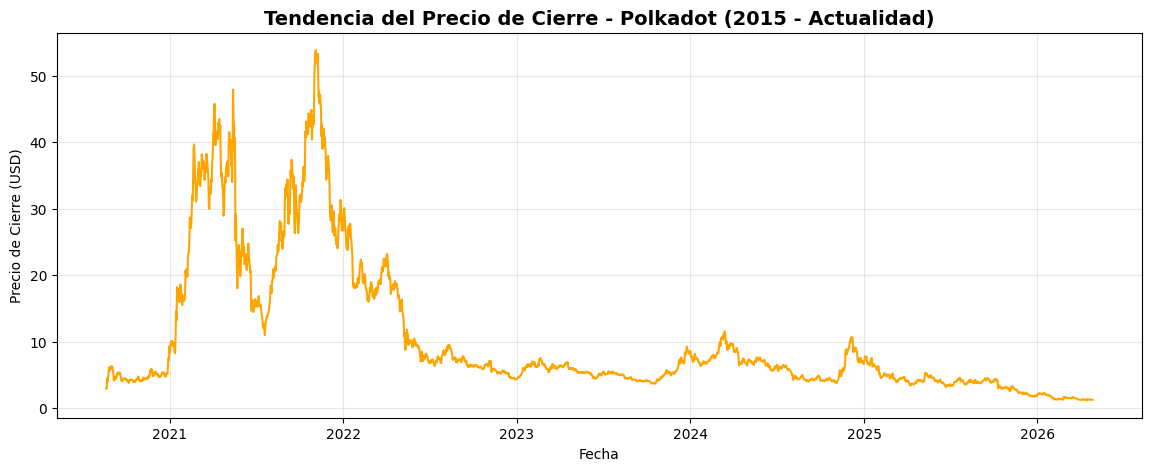


--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---
Total de registros (días): 2077
Media (Promedio):        $10.36 USD
Mediana (Valor central): $6.06 USD
Desviación Estándar:     $10.48 USD (Alta dispersión = Alta volatilidad)
Rango de Precios:        De $1.17 a $53.88 USD



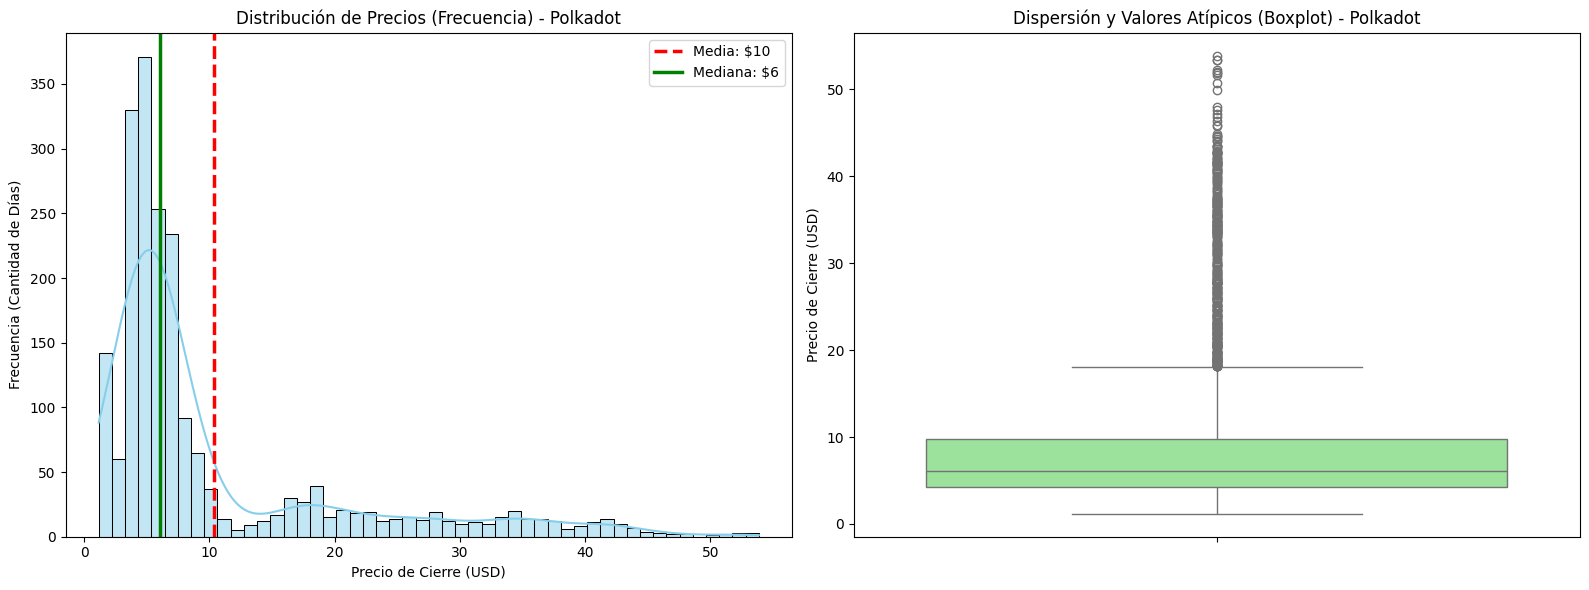

In [35]:
moneda = "Polkadot"
df_actual = crypto_database[moneda]

print(f"=== INICIANDO ANÁLISIS PARA: {moneda.upper()} ===\n")

plt.figure(figsize=(14, 5))
plt.plot(df_actual.index, df_actual['cierre'], color='orange', linewidth=1.5)
plt.title(f"Tendencia del Precio de Cierre - {moneda} (2015 - Actualidad)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.grid(True, alpha=0.3)
plt.show()

media = df_actual['cierre'].mean()
mediana = df_actual['cierre'].median()
desviacion = df_actual['cierre'].std()
minimo = df_actual['cierre'].min()
maximo = df_actual['cierre'].max()

print("\n--- MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ---")
print(f"Total de registros (días): {len(df_actual)}")
print(f"Media (Promedio):        ${media:,.2f} USD")
print(f"Mediana (Valor central): ${mediana:,.2f} USD")
print(f"Desviación Estándar:     ${desviacion:,.2f} USD (Alta dispersión = Alta volatilidad)")
print(f"Rango de Precios:        De ${minimo:,.2f} a ${maximo:,.2f} USD\n")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_actual['cierre'], bins=50, kde=True, color='skyblue', ax=ax[0])

ax[0].axvline(media, color='red', linestyle='--', linewidth=2.5, label=f'Media: ${media:,.0f}')
ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2.5, label=f'Mediana: ${mediana:,.0f}')
ax[0].set_title(f"Distribución de Precios (Frecuencia) - {moneda}", fontsize=12)
ax[0].set_xlabel("Precio de Cierre (USD)")
ax[0].set_ylabel("Frecuencia (Cantidad de Días)")
ax[0].legend()

sns.boxplot(y=df_actual['cierre'], color='lightgreen', ax=ax[1])
ax[1].set_title(f"Dispersión y Valores Atípicos (Boxplot) - {moneda}", fontsize=12)
ax[1].set_ylabel("Precio de Cierre (USD)")

plt.tight_layout()
plt.show()

-------------------------------






# Análisis de Correlación: Ejecutar una matriz de correlación de Pearson para determinar el grado de dependencia y movimiento conjunto entre las 10 criptomonedas seleccionadas.



#Hipotesis:

Existe la teoria de que las "Alt-coins", tienen una relacion con bitcoin.

--- BLOQUE: ANÁLISIS DE CORRELACIÓN DE PEARSON ---
1. Preparación de Datos: Unir los precios de'cierre' de todas las monedas en un solo DataFrame Usamos un diccionario por comprensión para extraer solo la columna 'cierre' de cada moneda.

2. Sincronización Temporal (Integridad):Como hay monedas más nuevas (ej. Polkadot lanzada en 2020), eliminamos las filas donde no hay datos para comparar todas bajo el mismo marco temporal.

3. Cálculo de la Matriz de Correlación el método 'pearson' mide la relación lineal entre -1 y +1.

4. Creación de Máscara Analítica usamos NumPy para ocultar el triángulo superior. Esto evita la redundancia visual y permite enfocarse en las relaciones únicas.

5. Visualización Profesional (Heatmap).
    Insertar los valores numéricos
    Dos decimales
    Paleta divergente (Rojo=Alta corr, Azul=Baja corr)
6. Mostrar el resultado final

7. Resumen de Integridad para el reporte

=== INICIANDO ANÁLISIS DE CORRELACIÓN DE PEARSON ===



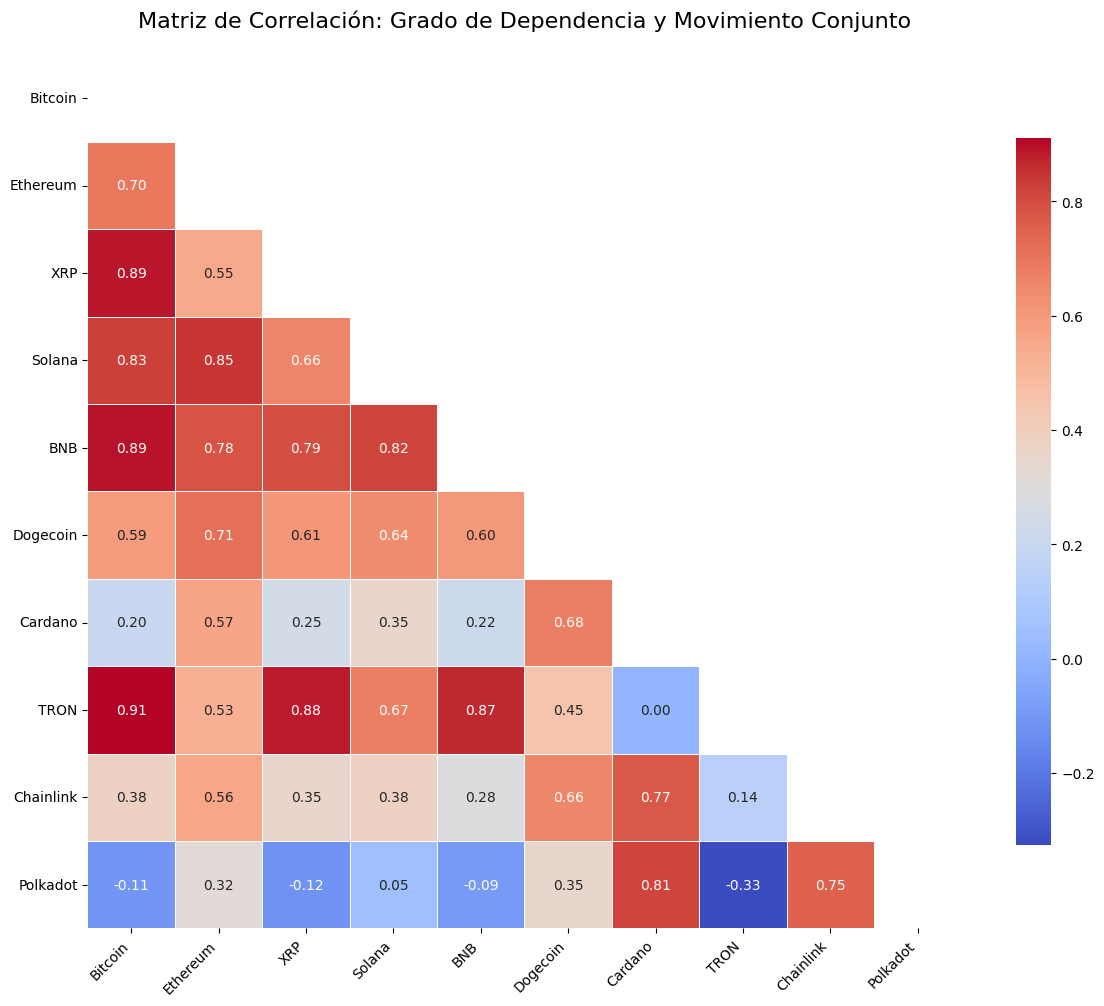


Análisis basado en 2077 días donde los 10 activos cotizaron simultáneamente.


In [36]:
print("=== INICIANDO ANÁLISIS DE CORRELACIÓN DE PEARSON ===\n")

datos_cierre = {nombre: df['cierre'] for nombre, df in crypto_database.items()}
df_correlacion = pd.DataFrame(datos_cierre)

df_correlacion.dropna(inplace=True)


matriz_corr = df_correlacion.corr(method='pearson')

mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_corr,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación: Grado de Dependencia y Movimiento Conjunto', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

print(f"\nAnálisis basado en {len(df_correlacion)} días donde los 10 activos cotizaron simultáneamente.")

#El Ranking de Dependencia (Gráfico de Barras)
Este código extrae exclusivamente la relación del mercado con Bitcoin.

--- PRUEBA DE HIPÓTESIS: DEPENDENCIA DE ALTCOINS HACIA BITCOIN ---

1. Aislamos la columna de Bitcoin de nuestra matriz ya calculada

2. Eliminamos a Bitcoin de la lista (porque la correlación de BTC con BTC siempre es 1.0)

3. Ordenamos de mayor a menor correlación

4. Visualización con Gráfico de Barras

5. Usamos un gráfico de barras para que el profesor vea claramente el ranking

6. Fijamos el límite Y de 0 a 1 para tener perspectiva real

7. Añadir el valor exacto sobre cada barra para mayor rigor

8. Detección automática de la altcoin más dependiente

=== EVALUANDO LA TEORÍA DE DEPENDENCIA HACIA BTC ===



/tmp/ipykernel_4627/623769539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlacion_btc.index, y=correlacion_btc.values, palette='Blues_r')


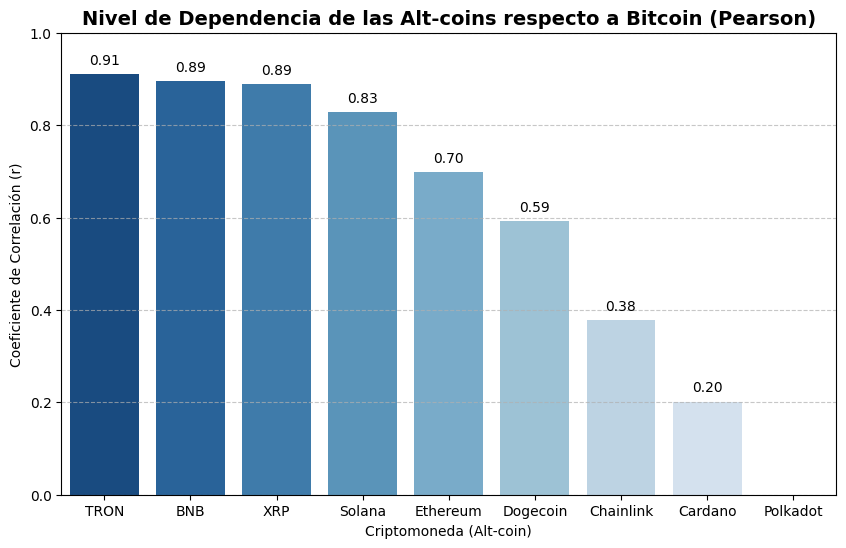


💡 RESULTADO DEL ANÁLISIS:
La Altcoin con mayor dependencia histórica hacia Bitcoin es TRON (r = 0.91).


In [37]:
print("=== EVALUANDO LA TEORÍA DE DEPENDENCIA HACIA BTC ===\n")

correlacion_btc = matriz_corr['Bitcoin'].copy()

correlacion_btc = correlacion_btc.drop('Bitcoin')

correlacion_btc = correlacion_btc.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

ax = sns.barplot(x=correlacion_btc.index, y=correlacion_btc.values, palette='Blues_r')

plt.title("Nivel de Dependencia de las Alt-coins respecto a Bitcoin (Pearson)", fontsize=14, fontweight='bold')
plt.ylabel("Coeficiente de Correlación (r)")
plt.xlabel("Criptomoneda (Alt-coin)")
plt.ylim(0, 1)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

altcoin_ganadora = correlacion_btc.index[0]
correlacion_ganadora = correlacion_btc.iloc[0]

print(f"\n💡 RESULTADO DEL ANÁLISIS:")
print(f"La Altcoin con mayor dependencia histórica hacia Bitcoin es {altcoin_ganadora.upper()} (r = {correlacion_ganadora:.2f}).")

# Demostración Visual de la Dependencia (Regresión Lineal)

--- DEMOSTRACIÓN MASIVA: REGRESIÓN DE TODAS LAS ALTCOINS VS BITCOIN ---

1. Obtenemos la lista de todas las monedas, excluyendo Bitcoin

2. Creamos una figura grande con una cuadrícula de 3 filas y 3 columnas

3. Aplanamos la matriz de ejes para poder iterar sobre ella fácilmente

4. Iteramos sobre cada altcoin y la dibujamos en su respectivo subgráfico

5. 's' es el tamaño del punto

6. Solo ponemos etiqueta X en la fila de abajo

7. Formateo del eje X (Bitcoin) para mostrar miles

8. Formateo dinámico del eje Y según el precio de la moneda

9. Monedas muy baratas (como Doge o Tron) necesitan más decimales

10. Ajustamos para que el título principal no se superponga

=== MAPEO GLOBAL DE DEPENDENCIA: BITCOIN VS MERCADO ===



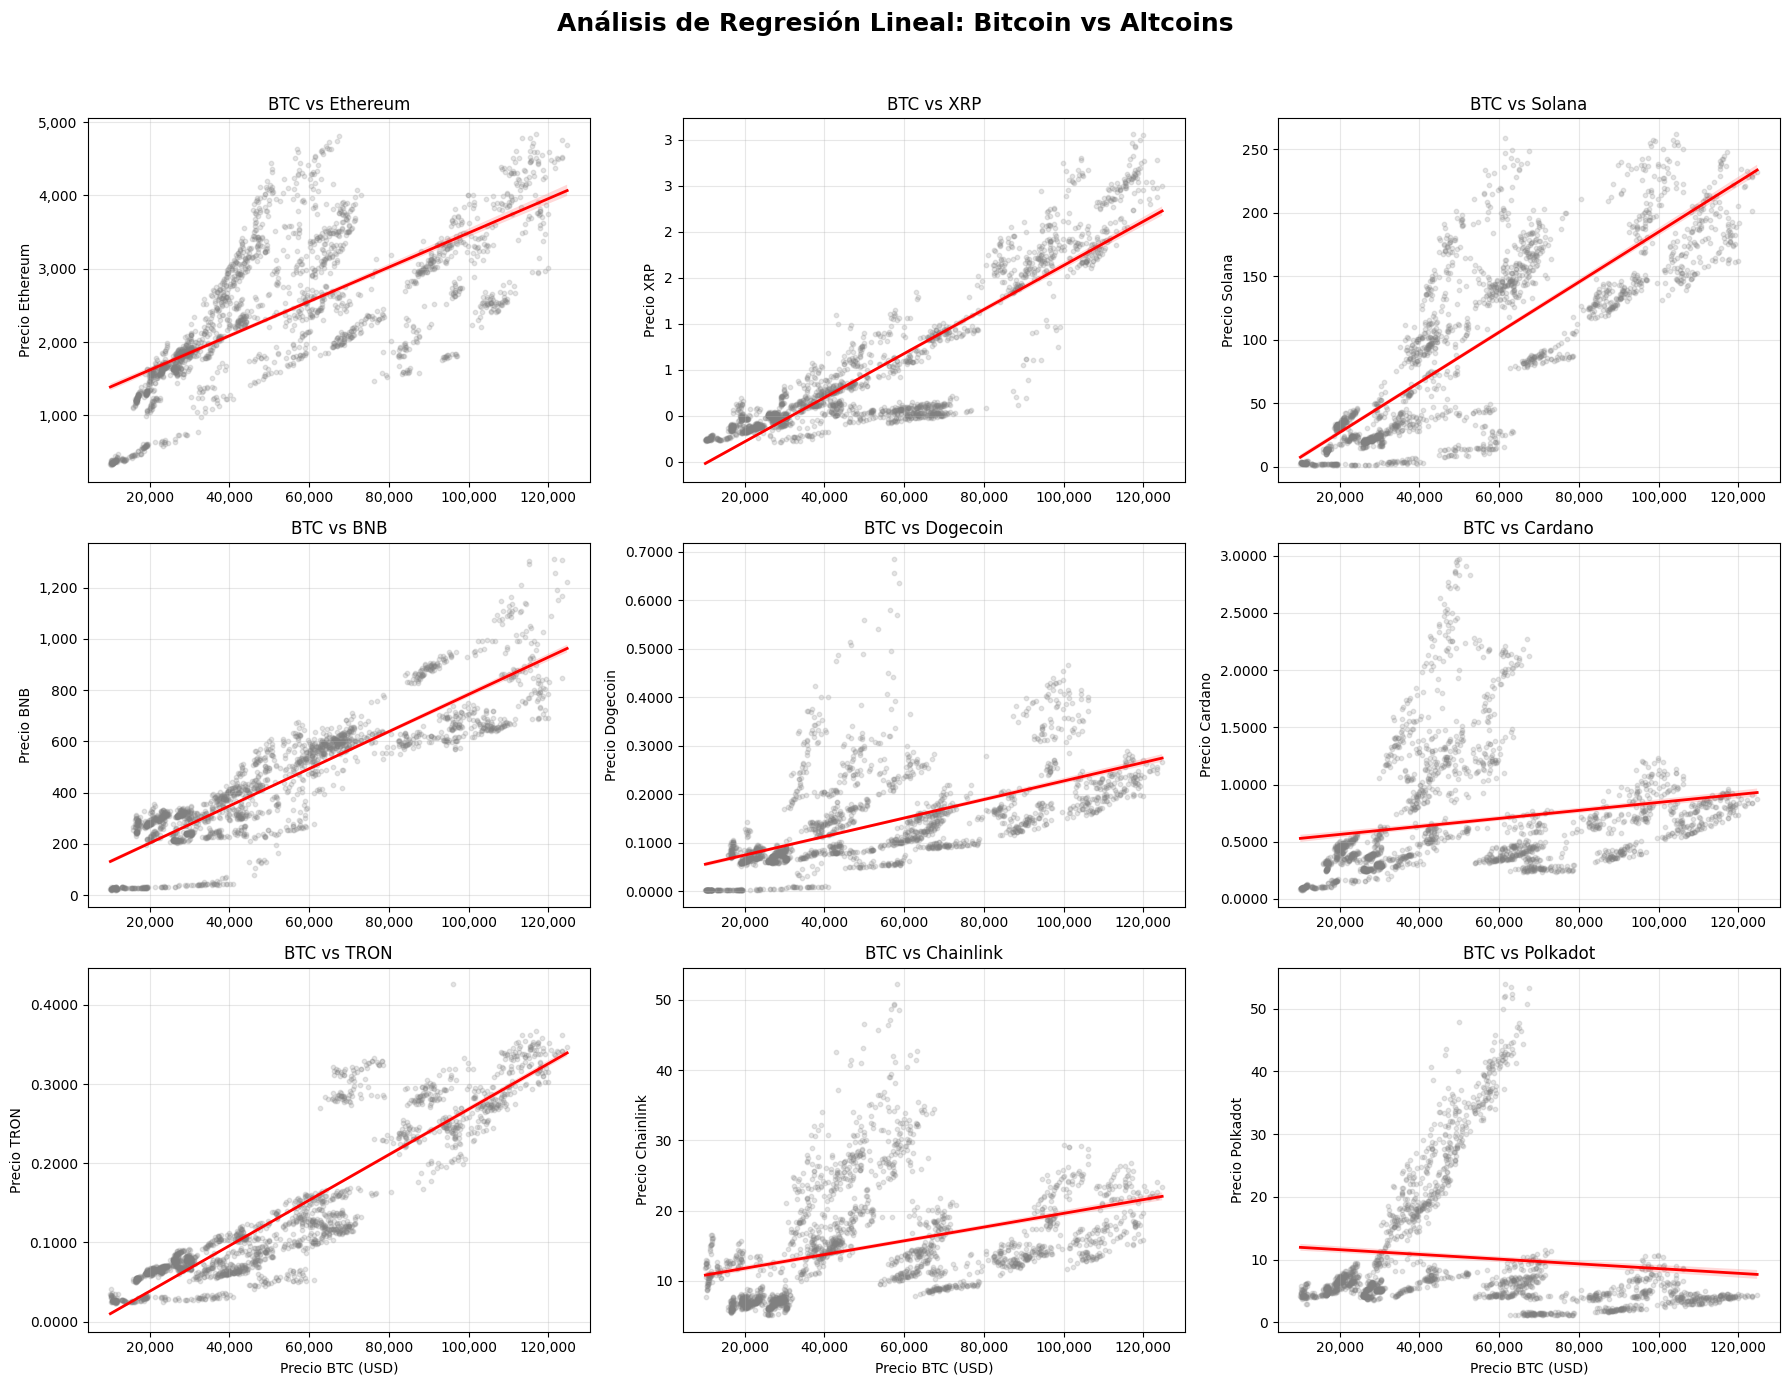


💡 OBSERVACIÓN DE MINERÍA DE DATOS:
Al visualizar todas las altcoins en conjunto, podemos comparar las pendientes (inclinación de la línea roja).
Líneas más empinadas y con puntos menos dispersos indican una mayor reactividad y dependencia al precio de Bitcoin.


In [38]:
print("=== MAPEO GLOBAL DE DEPENDENCIA: BITCOIN VS MERCADO ===\n")

altcoins = [moneda for moneda in df_correlacion.columns if moneda != 'Bitcoin']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle("Análisis de Regresión Lineal: Bitcoin vs Altcoins", fontsize=18, fontweight='bold', y=0.92)

axes = axes.flatten()

for i, altcoin in enumerate(altcoins):
    ax = axes[i]

    sns.regplot(
        x=df_correlacion['Bitcoin'],
        y=df_correlacion[altcoin],
        ax=ax,
        scatter_kws={'alpha':0.2, 'color':'gray', 's': 10},
        line_kws={'color':'red', 'linewidth':2}
    )

    ax.set_title(f"BTC vs {altcoin}", fontsize=12)
    ax.set_xlabel("Precio BTC (USD)" if i >= 6 else "")
    ax.set_ylabel(f"Precio {altcoin}")


    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))


    if df_correlacion[altcoin].mean() < 1:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"{y:.4f}"))
    else:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: format(int(y), ',')))

    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

print("\n💡 OBSERVACIÓN DE MINERÍA DE DATOS:")
print("Al visualizar todas las altcoins en conjunto, podemos comparar las pendientes (inclinación de la línea roja).")
print("Líneas más empinadas y con puntos menos dispersos indican una mayor reactividad y dependencia al precio de Bitcoin.")

# 4. Justificación de Herramientas y Librerías
* El desarrollo de este pipeline de Minería de Datos se sustentó en el ecosistema de Python, utilizando librerías especializadas para la extracción, estructuración, análisis y visualización de la información:

* Python: Lenguaje de programación base, elegido por su robustez, sintaxis declarativa y su amplio soporte en la industria de la Ciencia de Datos.

* YFinance: Librería utilizada como motor de Data Sourcing. Permitió la conexión a la API de Yahoo Finance para la extracción automatizada y masiva de los datos financieros históricos a nivel diario.

* Pandas (pd): Herramienta central del proyecto. Se utilizó para la manipulación de las estructuras de datos bidimensionales (DataFrames). Con ella se ejecutaron los procesos de limpieza (eliminación de duplicados y manejo de nulos con Forward/Backward Fill), el mapeo de columnas y el casting de tipos informáticos (conversión a numéricos continuos).

* Datetime: Módulo nativo de Python implementado para el manejo dinámico de fechas, garantizando que el pipeline siempre extraiga datos hasta el día exacto de la ejecución del código.

* Matplotlib (plt): Librería fundamental de graficación. Se empleó para definir la arquitectura de los lienzos (tamaños de figura), configurar los ejes y generar los gráficos de series de tiempo (tendencia histórica de precios).

* Seaborn (sns): Librería de visualización estadística de alto nivel. Fue clave para evaluar la salud de los datos y sus dependencias mediante la generación de histogramas de distribución, diagramas de caja (Boxplots) para la detección de valores atípicos (outliers), y el mapa de calor (Heatmap) de la Matriz de Correlación.

* NumPy (np): Librería de cálculo matricial avanzado. Su uso fue estrictamente necesario para la generación de matrices booleanas (np.triu y np.ones_like), lo que permitió crear una máscara analítica para limpiar visualmente el mapa de calor de correlación y darle un estándar profesional.


